# Решение задачи классификации с помощью kNN

## Цель и задачи  

В этом практическом задании вам предлагается самостоятельно обучить модель kNN для работы с многоклассовой классификацией. 
 
Вы уже знакомы с данными - это тот же датасет `song_data.csv`, содержащий характеристики музыкальных треков с платформы Spotify. Однако на этот раз нужно научиться предсказывать не рейтинг популярности, а дискретную целевую переменную (какую именно, вы можете выбрать сами).


**Цель:** Решить задачу классификации, провести эксперименты с параметрами, сравнить с базовой моделью и линейными моделями.   

При выполнении задания вы можете придерживаться предложенного плана или определить шаги самостоятельно.

**Рекомендуемый план работы:**

1. Загрузить данные и выбрать целевую переменную.
2. Провести предобработку данных (масштабирование).
3. Построить базовую модель.
4. Подобрать оптимальные гиперпараметры с помощью GridSearch:
    - n_neighbors
    - metric
    - weights
5. Обучить модель с лучшими гиперпараметрами и сравнить её с базовой.
6. Обучить модель логистической регресии и сравнить результаты с kNN.

## Данные

Давайте вспомним, какие признаки есть в датасете `song_data.csv`.

### Описание данных

- `song_duration_ms` — длительность трека в миллисекундах.
- `acousticness` — оценка акустичности (показывает, как много в треке "живой", а не электронной музыки). 
- `danceability` — оценка "танцевальности" трека. 
- `energy` — оценка энергичности трека. 
- `instrumentalness` — вероятность того, что трек не содержит вокал.
- `key` — музыкальный ключ, в котором написан трек (число от 0 до 11, соответствующее музыкальным нотам).
- `liveness` — вероятность того, что трек записан “вживую”. 
- `loudness` — громкость трека в децибелах.
- `audio_mode` — лад трека: 1 — мажорный, 0 — минорный. 
- `speechiness` — оценка “разговорности”: чем выше значение, тем больше в треке речевых фрагментов вместо пения.
- `tempo` — темп музыки в ударах в минуту (BPM).
- `audio_valence` — оценка "позитивности" настроения трека. 
- `time_signature` — ритмичность трека.
- `song_popularity` — индекс популярности трека на Spotify.

----

## 1. Загрузка данных и выделение целевой переменной

Прежде, чем переходить к работе, откроем датасет `song_data.csv` и очистим его от выбросов (логику обработки аномальных значений мы обсуждали в предыдущем уроке).

In [1]:
import pandas as pd

# Загружаем данные
df = pd.read_csv('./song_dataset.csv')

# Удаляем строки, содержащие аномальные значения
df = df[(df['song_duration_ms'] >= 60000) & (df['song_duration_ms'] <= 600000)]
df = df[(df['loudness'] >= -20) & (df['loudness'] <= 0)]
df = df[df['tempo'] >= 30]
df = df[df['time_signature'] != 0]

df.head()

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574


### Выбор целевой переменной

Чтобы решать задачу многоклассовой классификации, необходимо выделить признак, который может принимать одно из нескольких возможных значений (принадлежать одному из классов). 

Здесь есть несколько вариантов действий:  

1. Использовать `song_popularity`. Как и модель регрессии, модель классификации будет предсказывать популярность трека. Однако на этот раз предсказанием будет не точное число в диапазоне от 0 до 100, а "уровень" популярности (например, число от 0 до 9).  
    
    
2. Использовать другие непрерывные признаки - например, акустичность (`acousticness`), энергичность (`energy`) и т.д. Здесь вы можете поэкспериментировать - например, построить модель, которая оценивает, подходит ли трек для танцев.  
    
    
3. Использовать один готовых дискретных признаков (`key` или `time_signature`).  
  
  
Вы можете выбрать любой способ и сделать целевой переменной понравившийся признак - главное, чтобы его значения можно преобразовать в несколько категорий. Мы рекомендуем взять от 3 до 10 классов.

#### Дискретизация

Если вы хотите использовать первый или второй подход, нужно преобразовать выбранную непрерывную переменную в категориальную с ограниченным числом классов. Этот процесс называется **дискретизацией** (или **биннингом**). В `pandas` для этого удобно использовать метод `cut`.

In [2]:
df['popularity_class'] = pd.cut(
    df['song_popularity'], # Непрерывный признак для преобразования
    bins=10,               # Количество классов (рекомендуется выбрать число от 3 до 10)
    labels=False,          # Eсли False, в качестве меток используются номера интервалов (0, 1, ...)
)

# Результат: непрерывная и дискретная версия признака:
print(df[['song_popularity', 'popularity_class']].head())

   song_popularity  popularity_class
0               73                 7
1               66                 6
2               76                 7
3               74                 7
4               56                 5


Далее приведено несколько примеров того, как можно подготовить целевую переменную. Вы можете выбрать понравившийся вариант или релаизовать свой по аналогии.

#### Пример 1
Преобразование непрерывного значения `song_popularity` в 3 класса.

In [4]:
df = pd.read_csv('./song_dataset.csv')

df = df[(df['song_duration_ms'] >= 60000) & (df['song_duration_ms'] <= 600000)]
df = df[(df['loudness'] >= -20) & (df['loudness'] <= 0)]
df = df[df['tempo'] >= 30]
df = df[df['time_signature'] != 0]


df['song_popularity'] = pd.cut(
    df['song_popularity'],
    bins=3,               
    labels=False,          
)

# Проверим распределение классов
df['song_popularity'].value_counts()

song_popularity
1    962
2    724
0    200
Name: count, dtype: int64

#### Пример 2
Преобразование непрерывного значения `danceability` в бинарный признак.
Такой таргет будет показывать, подходит ли трек для танцев. Например, если значение признака больше 0.7, композицию можно считать "танцевальной".

In [6]:
df = pd.read_csv('./song_dataset.csv')

df = df[(df['song_duration_ms'] >= 60000) & (df['song_duration_ms'] <= 600000)]
df = df[(df['loudness'] >= -20) & (df['loudness'] <= 0)]
df = df[df['tempo'] >= 30]
df = df[df['time_signature'] != 0]

# Сравниванием значение с порогом
df['is_danceable'] = (df['danceability'] > 0.7).astype(int) 
# Удаляем исходный признак
df = df.drop(columns=['danceability']) 

# Проверим распределение классов
df['is_danceable'].value_counts()

is_danceable
0    1403
1     483
Name: count, dtype: int64

### Преобразование признака

Прежде, чем двигаться дальше, выполниите дискретизацию выбранного признака.   

**Не забудьте удалить из датасета исходный признак, чтобы избежать утечки данных!**

In [18]:
df['popularity_class'] = pd.cut(
    df['song_popularity'],
    bins=10,
    labels=False,
)

print(df[['song_popularity', 'popularity_class']].head(5))

X = df.drop(columns=['popularity_class', 'song_popularity'])
y = df['popularity_class']

   song_popularity  popularity_class
0               73                 7
1               66                 6
2               76                 7
3               74                 7
4               56                 5


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    test_size=.2,
    random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (1508, 13)
Размер тестовой выборки: (378, 13)
Среднее значенее целевой переменной в train: 5.434
Среднее значенее целевой переменной в test: 5.307


----

## 2. Масштабирование признаков

Чтобы модель kNN работала корректно, используйте `ColumnTransformer` для масштабирования числовых признаков.  
  
**Возможные эксперименты**   
При желании вы можете провести небольшие исследования. Например:
- Обучить модель на исходных и отмасштабированных данных и сравнить качество предсказаний.
- Использовать `StandardScaler` и `MinMaxScaler` и оценить, какой подход даёт лучшие результаты.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), X_train.columns)
])

----

## 3. Построение базовой модели

Базовая модель (baseline) используется для того, чтобы оценить сложность задачи и то, какие приросты дают более сложные подходы. Для этого нужно обучить класс `KNeighborsClassifier` с параметрами по умолчанию и посчитать качество (не забудьте поделить данные на обучающие, валидационные и тестовые).
  
Для удобства вы можете объединить трансформер и модель в один пайплайн с помощью класса `Pipeline`.

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

def confusion_matrix_heatmap(matrix):
    ax = sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)
    ax.set_title(f'Матрица ошибок')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    
    plt.show()
    plt.close()

Обучающая выборка (f1_score macro): 0.36
Тестовая выборка (f1_score macro): 0.17

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00        10
           3       0.35      0.33      0.34        18
           4       0.09      0.05      0.07        38
           5       0.22      0.28      0.25        72
           6       0.37      0.44      0.40       116
           7       0.27      0.26      0.26        82
           8       0.00      0.00      0.00         9
           9       0.67      0.29      0.40         7

    accuracy                           0.27       378
   macro avg       0.20      0.16      0.17       378
weighted avg       0.25      0.27      0.26       378




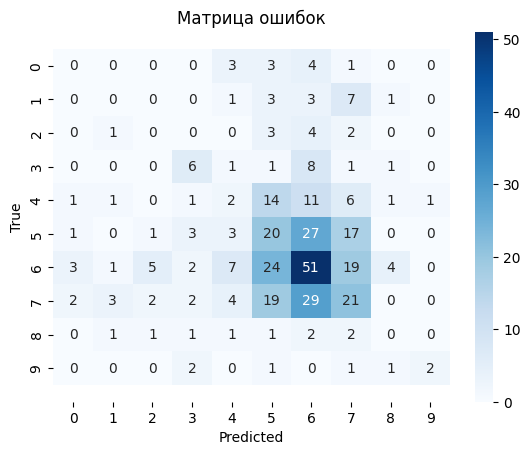

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

pipe.fit(X_train, y_train)

train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print(f"Обучающая выборка (f1_score macro): {f1_score(y_train, train_pred, average='macro'):.2}")
print(f"Тестовая выборка (f1_score macro): {f1_score(y_test, test_pred, average='macro'):.2}")
print()
print(classification_report(y_test, test_pred, zero_division=0))    
print()
confusion_matrix_heatmap(confusion_matrix(y_test, test_pred))

----

## 4. Подбор гиперпараметров

Подбор гиперпараметров часто позволяет значительно улучшить качетство модели. Для перебора различных комбинаций с использованием кросс-валидации используйте класс `GridSearchCV`.

Напомним, что при решении задачи регрессии вы перебирали такие наборы гиперпараметров:
- `n_neighbors` (количество соседей): [3, 5, 10, 15, 20, 25, 30].
- `weights` (способ взвешивания): [`uniform`, `distance`].
- `metric` (метрика расстояния): `minkowski` с подбором `p` = [1, 2, 3, 4]. 

Вы можете вновь использовать эти значения или выбрать свои диапазоны.

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'model__n_neighbors': [3, 5, 10, 15, 20, 25, 30],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['minkowski'],
        'model__p': [1, 2, 3, 4]
    }
]

knn_grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=3,
    return_train_score=False
)

print("Начинаем подбор гиперпараметров...")
knn_grid_search.fit(X_train, y_train)

Начинаем подбор гиперпараметров...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'distance'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__metric': ['minkowski'], 'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2, ...], 'model__weights': ['uniform', 'distance']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [70]:
results_df = pd.DataFrame(knn_grid_search.cv_results_)
results_df['Model'] = 'KNN'

def format_params(params):
    return ", ".join(
        f"{key.replace('model__', '')}={val}" 
        for key, val in params.items() 
        if key != 'model'
    )

results_df['Params'] = results_df['params'].apply(format_params)

columns_to_show = [
    'Model', 
    'Params', 
    'mean_test_score', 
    'std_test_score',
    'rank_test_score'
]

results_table = results_df[columns_to_show].sort_values(by='rank_test_score')
results_table.columns = ['Model', 'Hyperparameters', 'F1 (macro)', 'Std Dev', 'Rank']

print("Топ-10 лучших моделей:")
pd.set_option('display.max_colwidth', None)
results_table.head(10)

Топ-10 лучших моделей:


,Model,Hyperparameters,F1 (macro),Std Dev,Rank
5,KNN,"metric=minkowski, n_neighbors=3, p=3, weights=distance",0.169190,0.024493,1
1,KNN,"metric=minkowski, n_neighbors=3, p=1, weights=distance",0.168520,0.018539,2
21,KNN,"metric=minkowski, n_neighbors=10, p=3, weights=distance",0.165418,0.038246,3
13,KNN,"metric=minkowski, n_neighbors=5, p=3, weights=distance",0.165120,0.025044,4
9,KNN,"metric=minkowski, n_neighbors=5, p=1, weights=distance",0.164870,0.028236,5
7,KNN,"metric=minkowski, n_neighbors=3, p=4, weights=distance",0.164821,0.024553,6
53,KNN,"metric=minkowski, n_neighbors=30, p=3, weights=distance",0.164752,0.007465,7
11,KNN,"metric=minkowski, n_neighbors=5, p=2, weights=distance",0.164287,0.026864,8
3,KNN,"metric=minkowski, n_neighbors=3, p=2, weights=distance",0.164155,0.021354,9
55,KNN,"metric=minkowski, n_neighbors=30, p=4, weights=distance",0.162873,0.007801,10


----

## 5. Обучение лучшей модели

После определения оптимальных гиперпараметров можно обучить лучшую версию модели и сравнить её качество с базовой версией.

Обучающая выборка (f1_score macro): 1.0
Тестовая выборка (f1_score macro): 0.2

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.21      0.20      0.21        15
           2       0.00      0.00      0.00        10
           3       0.24      0.22      0.23        18
           4       0.13      0.11      0.12        38
           5       0.24      0.26      0.25        72
           6       0.38      0.39      0.38       116
           7       0.32      0.34      0.33        82
           8       0.14      0.22      0.17         9
           9       0.25      0.29      0.27         7

    accuracy                           0.28       378
   macro avg       0.19      0.20      0.20       378
weighted avg       0.27      0.28      0.28       378




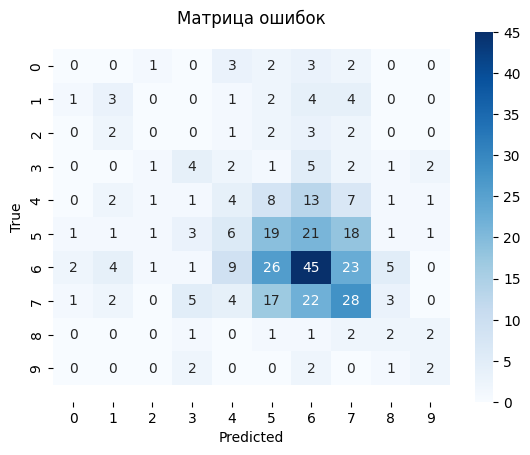

In [71]:
pipe.set_params(**knn_grid_search.best_params_)
pipe.fit(X_train, y_train)

train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print(f"Обучающая выборка (f1_score macro): {f1_score(y_train, train_pred, average='macro'):.2}")
print(f"Тестовая выборка (f1_score macro): {f1_score(y_test, test_pred, average='macro'):.2}")
print()
print(classification_report(y_test, test_pred, zero_division=0))    
print()
confusion_matrix_heatmap(confusion_matrix(y_test, test_pred))

## 6. Сравнение с линейными моделями

На этом этапе вы можете оценить эффективность kNN по сравнению с другими моделями для многоклассовой классификации.

**Возможные эксперименты:** 
- Обучить одну из линейных моделей (OvR, OvO, многоклассовый логрег) с подбором гиперпараметров и сравнить качество с kNN.
- Оценить время обучения kNN и линейных моделей, а также сравнить время, необходимое для предсказания.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
RANDOM_STATE = 42

param_grid = [
    {
        'model': [LogisticRegression(
            solver='lbfgs', 
            class_weight='balanced', 
            max_iter=3000,
            random_state=RANDOM_STATE,
        )],
        'model__C': [0.01, 0.1, 1, 10],
    },
    {
        'model': [LogisticRegression(
            solver='saga', 
            class_weight='balanced', 
            max_iter=3000,
            random_state=RANDOM_STATE
        )],
        'model__C': [0.01, 0.1, 1, 10],
        'model__l1_ratio': [0, 0.5, 1],
    },
    {
        'model': [OneVsOneClassifier(LinearSVC(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE))],
        'model__estimator__C': [0.01, 0.1, 1, 10],
        'model__estimator__penalty': ['l1', 'l2']
    },
    {
        'model': [OneVsOneClassifier(LogisticRegression(solver='saga', max_iter=3000, random_state=RANDOM_STATE))],
        'model__estimator__C': [0.01, 0.1, 1, 10],
        'model__estimator__l1_ratio': [0, 0.5, 1],
    },
    {
        'model': [OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE))],
        'model__estimator__C': [0.01, 0.1, 1, 10],
        'model__estimator__penalty': ['l1', 'l2']
    },
    {
        'model': [OneVsRestClassifier(LogisticRegression(solver='saga', max_iter=3000, random_state=RANDOM_STATE))],
        'model__estimator__C': [0.01, 0.1, 1, 10],
        'model__estimator__l1_ratio': [0, 0.5, 1],
    }
]

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=3,
    return_train_score=False
)

print("Начинаем подбор гиперпараметров...")
grid_search.fit(X_train, y_train)

Начинаем подбор гиперпараметров...


/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/katsay/develop/ml/venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/katsay/develop/ml/venv/

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'distance'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.01, 0.1, ...]}, {'model': [LogisticRegre...solver='saga')], 'model__C': [0.01, 0.1, ...], 'model__l1_ratio': [0, 0.5, ...]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, th

In [73]:
results_df = pd.DataFrame(grid_search.cv_results_)

def get_model_name(estimator):
    if pd.isnull(estimator) or isinstance(estimator, float):
        return "N/A"

    if hasattr(estimator, 'steps'):
        return estimator.steps[-1][1].__class__.__name__
    
    if hasattr(estimator, 'estimator'):
        return estimator.estimator.__class__.__name__
    
    return estimator.__class__.__name__

results_df['Model'] = results_df['param_model'].apply(get_model_name)

def format_params(params):
    return ", ".join(
        f"{key.replace('model__', '')}={val}" 
        for key, val in params.items() 
        if key != 'model'
    )

results_df['Params'] = results_df['params'].apply(format_params)

columns_to_show = [
    'Model', 
    'Params', 
    'mean_test_score', 
    'std_test_score',
    'rank_test_score'
]

results_table = results_df[columns_to_show].sort_values(by='rank_test_score')
results_table.columns = ['Model', 'Hyperparameters', 'F1 (macro)', 'Std Dev', 'Rank']

print("Топ-10 лучших моделей:")
pd.set_option('display.max_colwidth', None)
results_table.head(10)

Топ-10 лучших моделей:


,Model,Hyperparameters,F1 (macro),Std Dev,Rank
33,LogisticRegression,"estimator__C=10, estimator__l1_ratio=0",0.117903,0.015969,1
35,LogisticRegression,"estimator__C=10, estimator__l1_ratio=1",0.117785,0.015567,2
34,LogisticRegression,"estimator__C=10, estimator__l1_ratio=0.5",0.116747,0.016972,3
31,LogisticRegression,"estimator__C=1, estimator__l1_ratio=0.5",0.116157,0.023439,4
32,LogisticRegression,"estimator__C=1, estimator__l1_ratio=1",0.113339,0.020781,5
30,LogisticRegression,"estimator__C=1, estimator__l1_ratio=0",0.110628,0.021111,6
55,LogisticRegression,"estimator__C=10, estimator__l1_ratio=1",0.109539,0.020340,7
53,LogisticRegression,"estimator__C=10, estimator__l1_ratio=0",0.109389,0.020213,8
54,LogisticRegression,"estimator__C=10, estimator__l1_ratio=0.5",0.109380,0.020205,9
50,LogisticRegression,"estimator__C=1, estimator__l1_ratio=0",0.109138,0.020499,10


Тестовая выборка (f1_score macro): 0.2
kNN: Train=0.0026s, Predict=0.0309s

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.21      0.20      0.21        15
           2       0.00      0.00      0.00        10
           3       0.24      0.22      0.23        18
           4       0.13      0.11      0.12        38
           5       0.24      0.26      0.25        72
           6       0.38      0.39      0.38       116
           7       0.32      0.34      0.33        82
           8       0.14      0.22      0.17         9
           9       0.25      0.29      0.27         7

    accuracy                           0.28       378
   macro avg       0.19      0.20      0.20       378
weighted avg       0.27      0.28      0.28       378




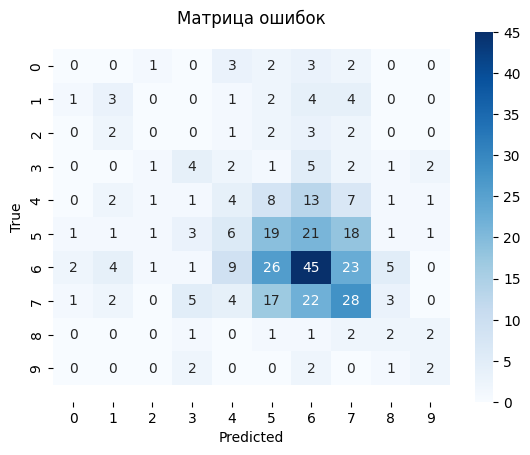

Тестовая выборка (f1_score macro): 0.074
Linear: Train=0.1482s, Predict=0.0033s

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        15
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        18
           4       0.00      0.00      0.00        38
           5       0.19      0.04      0.07        72
           6       0.29      0.58      0.39       116
           7       0.25      0.34      0.29        82
           8       0.00      0.00      0.00         9
           9       0.00      0.00      0.00         7

    accuracy                           0.26       378
   macro avg       0.07      0.10      0.07       378
weighted avg       0.18      0.26      0.19       378




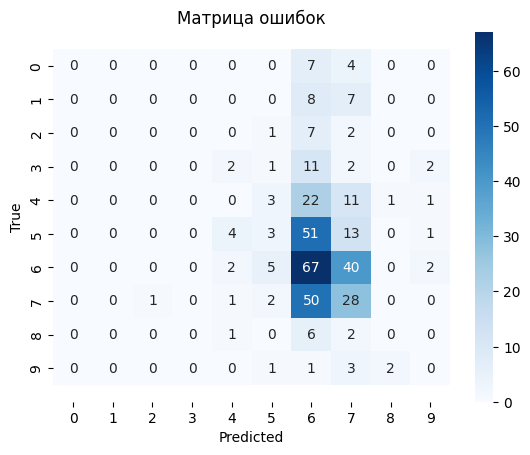

In [74]:
import time

pipe.set_params(**knn_grid_search.best_params_)
start_train = time.time()
pipe.fit(X_train, y_train)
end_train = time.time()
start_pred = time.time()
test_pred = pipe.predict(X_test)
end_pred = time.time()

knn_train_time = end_train - start_train
knn_pred_time = end_pred - start_pred

print(f"Тестовая выборка (f1_score macro): {f1_score(y_test, test_pred, average='macro'):.2}")
print(f"kNN: Train={knn_train_time:.4f}s, Predict={knn_pred_time:.4f}s")
print()
print(classification_report(y_test, test_pred, zero_division=0))    
print()
confusion_matrix_heatmap(confusion_matrix(y_test, test_pred))

pipe.set_params(**grid_search.best_params_)
start_train = time.time()
pipe.fit(X_train, y_train)
end_train = time.time()
start_pred = time.time()
test_pred = pipe.predict(X_test)
end_pred = time.time()

linear_train_time = end_train - start_train
linear_pred_time = end_pred - start_pred

print(f"Тестовая выборка (f1_score macro): {f1_score(y_test, test_pred, average='macro'):.2}")
print(f"Linear: Train={linear_train_time:.4f}s, Predict={linear_pred_time:.4f}s")
print()
print(classification_report(y_test, test_pred, zero_division=0))    
print()
confusion_matrix_heatmap(confusion_matrix(y_test, test_pred))

---